In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import shap
import pickle
import logging
import matplotlib.pyplot as plt

In [3]:
# Initialize logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [4]:
# Load your dataset
try:
    df = pd.read_csv('testing_data_final.csv')  # Make sure to replace with your dataset's path
    logging.info("Dataset loaded successfully.")
except FileNotFoundError:
    logging.error("Dataset file not found. Please check the file path.")
    raise
except Exception as e:
    logging.error(f"An error occurred while loading the dataset: {e}")
    raise

2024-02-25 19:11:30,771 - INFO - Dataset loaded successfully.


In [5]:
# Define the features and the target variable based on your dataset
features = [
    'sem_present_count', 'sem_absent_count', 'sem_eval_lec_test_1_mark',
    'sem_eval_lab_test_1_mark', 'semester_evaluation_mid_mark',
    'sem_eval_lec_test_2_mark', 'sem_eval_lab_test_2_mark',
    'semester_evaluation_pre_gtu_mark', 'semester_evaluation_internal_mark'
]
target = 'semester_evaluation_gtu_mark'

X = df[features]
y = df[target]

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
logging.info("Data split into training and testing sets.")

2024-02-25 19:11:58,242 - INFO - Data split into training and testing sets.


In [7]:
# Scale the feature data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logging.info("Feature scaling completed.")

2024-02-25 19:12:08,733 - INFO - Feature scaling completed.


In [8]:
# Train a RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
logging.info("Random forest regressor model trained.")

2024-02-25 19:12:17,097 - INFO - Random forest regressor model trained.


In [9]:
# Evaluate the model
predictions = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
logging.info(f"Model evaluation - MAE: {mae}, MSE: {mse}, RMSE: {rmse}")

2024-02-25 19:12:26,157 - INFO - Model evaluation - MAE: 1.5257142857142867, MSE: 3.8746857142857194, RMSE: 1.9684221382329856


In [10]:
# Create a SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_scaled)

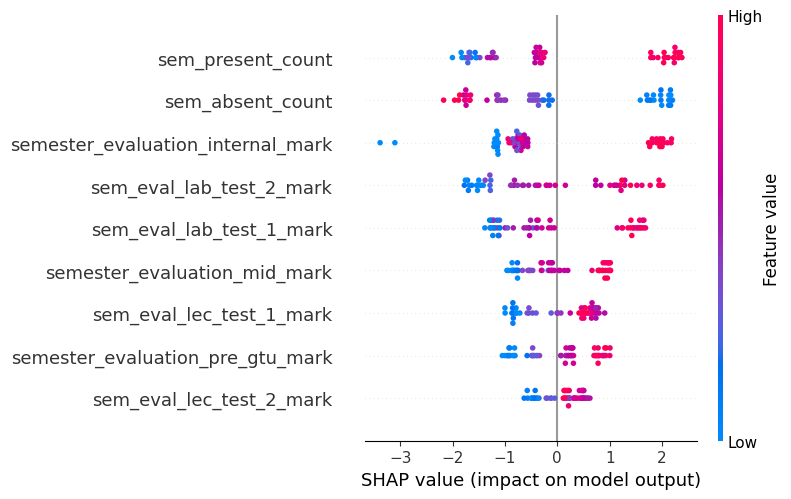

2024-02-25 19:15:28,423 - INFO - SHAP summary plot generated and saved to 'shap_summary_plot.png'.


<Figure size 640x480 with 0 Axes>

In [14]:
# Visualize the SHAP values with a summary plot
plt.figure()
shap.summary_plot(shap_values, X_train_scaled, feature_names=features)
plt.savefig('shap_summary_plot.png')
logging.info("SHAP summary plot generated and saved to 'shap_summary_plot.png'.")

In [11]:
# Save the model, scaler, and SHAP explainer to disk
with open('model.pkl', 'wb') as f_model, open('scaler.pkl', 'wb') as f_scaler, open('shap_explainer.pkl', 'wb') as f_explainer:
    pickle.dump(model, f_model)
    pickle.dump(scaler, f_scaler)
    pickle.dump(explainer, f_explainer)

logging.info("Model, scaler, and SHAP explainer have been saved to disk.")

2024-02-25 19:12:46,467 - INFO - Model, scaler, and SHAP explainer have been saved to disk.
